# 🏛️ Итоговое домашнее задание
# «Аналитик реестра — Обработка данных ЕФРСБ»





Вы — юрист, анализирующий данные из **Единого федерального реестра сведений о банкротстве (ЕФРСБ)**.
Вам поступила выгрузка в формате JSON с информацией о сообщениях по делам о банкротстве за 2025 год.

**Ваша задача** — извлечь ключевые данные, очистить от мусора, сопоставить с реестром организаций
и сформировать аналитический отчёт для руководства.

---
### 📋 Как выполнять и сдавать задание

**Где выполнять:**
- **Вариант 1 (рекомендуется):** Загрузите файл `.ipynb` в [Google Colab](https://colab.research.google.com/), загрузите папку `final_hw_data/` в среду выполнения (например, через боковую панель «Файлы» или смонтировав Google Drive).
- **Вариант 2:** Работайте локально в Jupyter Notebook / JupyterLab. Убедитесь, что папка `final_hw_data/` находится в той же директории, что и файл задания.

**Как сдавать на проверку:**
- Отправьте **ссылку на Google Colab** с общим доступом («Любой, у кого есть ссылка — комментатор»), **ИЛИ**
- Отправьте **ссылку на GitHub-репозиторий**, в котором лежит выполненный `.ipynb`-файл и папка `final_hw_data/` с результатами.

> ⚠️ Убедитесь, что ссылка открывается в режиме просмотра и все ячейки выполнены (результаты видны).

---

### 📦 Исходные данные

В папке `final_hw_data/` находятся 3 файла:

| Файл | Описание |
|------|----------|
| `bankruptcy_messages.json` | Сообщения ЕФРСБ |
| `organizations.json` | Реестр организаций |
| `priority_cases.txt` | Номера приоритетных дел |



---
# 🟢 Загрузка и кросс-референс (0-2 балла)
---

### Задание 1.1 — Загрузка данных из файлов

Загрузите данные из трёх файлов:
- `bankruptcy_messages.json` → список `messages`
- `organizations.json` → список `organizations`
- `priority_cases.txt` → список `priority_case_numbers`

Выведите количество загруженных записей из каждого источника.

In [201]:
import json

from pandas.tseries.frequencies import key

with open('bankruptcy_messages.json', 'r', encoding='utf-8') as f:
    messages = json.load(f)
    print(f"Длинна messages: {len(messages)}")
with open('organizations.json', 'r', encoding='utf-8') as f:
    organizations = json.load(f)
    print(f"Длина organizations: {len(organizations)}")
with open('priority_cases.txt', 'r', encoding='utf-8') as f:
    #очищаем строки и добавляем только непустые
    priority_case_numbers = [line.strip() for line in f if line.strip()]
    print(f"Длина priority_case_numbers: {len(priority_case_numbers)}")


Длинна messages: 54
Длина organizations: 30
Длина priority_case_numbers: 10


### Задание 1.2 — Словарь организаций

Создайте словарь `org_by_inn`, где ключ — ИНН (строка), а значение — словарь с данными об организации.
Используйте **dict comprehension**.

Выведите количество организаций в словаре и информацию по ИНН `"7701234567"`.

In [202]:
import pandas as pd
try:
    org_by_inn = {org['inn']: org for org in organizations}
except KeyError:
    print('Слоаврь уже преобразован')
#удаляем inn из внутреннего словаря
for org in org_by_inn.values():
    org.pop("inn", None)
print(f"Количество организаций в словаре: {len(org_by_inn)}")
inn_to_check = "7701234567"
org_info = org_by_inn.get(inn_to_check)
if org_info:
    print(f"Информация по ИНН {inn_to_check}: {org_info}")
else:
    print(f"Организация с ИНН {inn_to_check} не найдена.")

Количество организаций в словаре: 30
Информация по ИНН 7701234567: {'ogrn': '1027700123456', 'name': 'ООО "Альфа-Строй"', 'address': 'г. Москва, ул. Строителей, д. 15', 'region': 'Москва'}


In [203]:
import pandas as pd
#преобразуем полученный словарь в dataframe, если будет необходимость использовать pandas
#в качестве индекса установим ключ inn
org_df = pd.DataFrame.from_dict(org_by_inn, orient="index")
org_df.index.name = "inn"
org_df = org_df.reset_index()

org_df.head()

,inn,ogrn,name,address,region
0,7701234567,1027700123456,"ООО ""Альфа-Строй""","г. Москва, ул. Строителей, д. 15",Москва
1,7702345678,1037700234567,"ЗАО ""Бета-Инвест""","г. Москва, пр-т Мира, д. 42",Москва
2,6658123450,1026600123450,"ООО ""Гамма-Трейд""","г. Екатеринбург, ул. Ленина, д. 50",Свердловская область
3,7810345612,1047800345612,"ОАО ""Дельта-Логистик""","г. Санкт-Петербург, Невский пр-т, д. 100",Санкт-Петербург
4,5027123456,1035002123456,"ООО ""Омега-Финанс""","г. Краснодар, ул. Красная, д. 30",Краснодарский край


<Axes: >

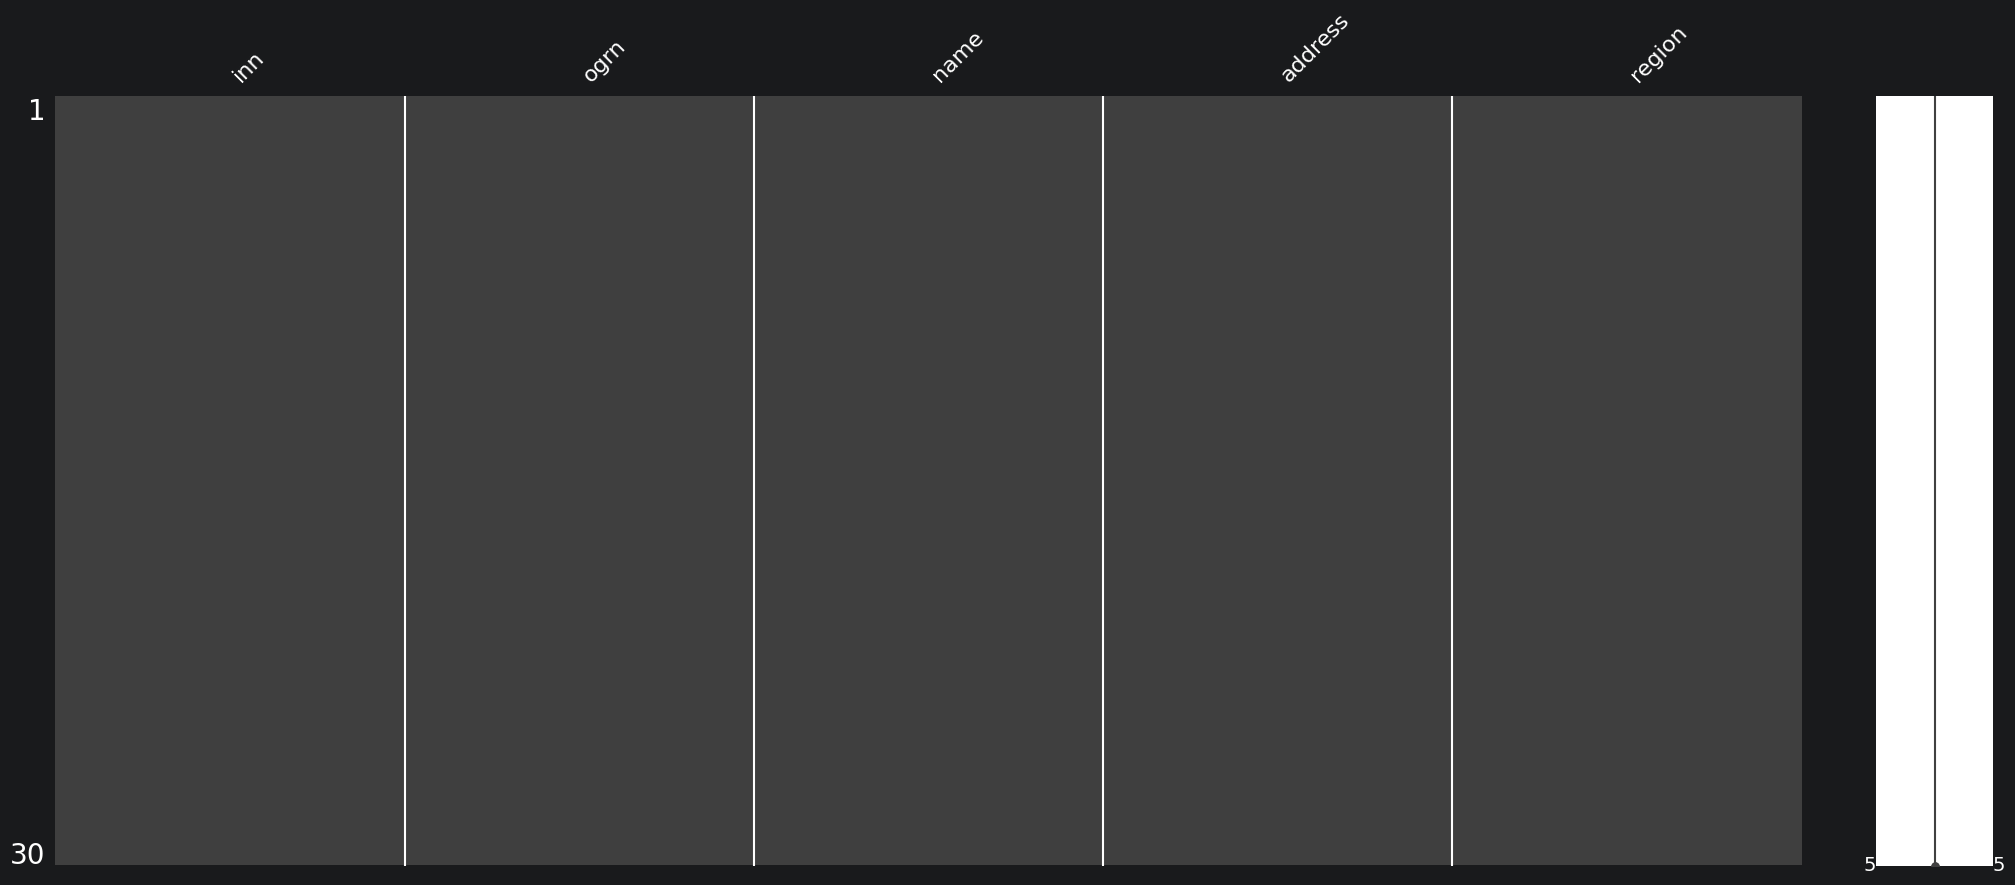

In [204]:
#проверим графическим способом данные на наличие пропусков
import missingno as msno
msno.matrix(org_df)

In [205]:
#преобразуем messages в dataframe

messages_df = pd.DataFrame(messages)
messages_df.head()

,publisher_inn,msg_text,date_published,type,case_number
0,7701234567,Сообщение о введении процедуры наблюдения в от...,15.01.2025,Введение процедуры,А60-12345/2025
1,7702345678,Уведомление о проведении собрания кредиторов З...,2025-02-10,Собрание кредиторов,А60-56789/2025
2,6658123450,Сообщение о завершении конкурсного производств...,2025-03-15T00:00:00,Завершение процедуры,А60-11111/2025
3,7810345612,Сообщение о признании должника банкротом. ОАО ...,20 марта 2025 г.,Признание банкротом,А60-22222/2025
4,5027123456,Уведомление о продаже имущества должника. ООО ...,2025-04-05,Продажа имущества,А60-33333/2025


### Задание 1.3 — Кросс-референс: связываем сообщения с организациями

Для каждого сообщения добавьте поле `org_name` (название организации) и `region`,
используя словарь `org_by_inn` и метод `.get()`.
Если организация не найдена — ставьте значение `None`.

Посчитайте, сколько сообщений удалось связать с организацией,
а сколько — не удалось.

In [206]:
count_linked = 0
count_unlinked = 0
for msg in messages:
    org_info = org_by_inn.get(msg["publisher_inn"])
    if org_info:
        msg["org_name"] = org_info.get("name")
        msg["region"] = org_info.get("region")
        count_linked += 1
    else:
        msg["org_name"] = None
        msg["region"] = None
        count_unlinked += 1
print(f"Связано: {count_linked} сообщений")
print(f"Не связано: {count_unlinked} сообщений")

Связано: 51 сообщений
Не связано: 3 сообщений


In [207]:
#делаем ту же операцию, но через pandas
messages_enriched = messages_df.merge(
    org_df[["inn", "name", "region"]],
    how="left",
    left_on="publisher_inn",
    right_on="inn"
)
#переименовываем столбец name в org_name
messages_enriched = messages_enriched.rename(columns={"name": "org_name"})
#удаляем столбец ИНН, так как он дублируется с publisher_inn
messages_enriched = messages_enriched.drop(columns=["inn"])
#считаем связанные/несвязанные значения
сount_linked_pd = messages_enriched["org_name"].notna().sum()
count_unlinked_pd = messages_enriched["org_name"].isna().sum()

print(f"Связано (pandas): {сount_linked_pd} сообщений")
print(f"Не связано (pandas): {count_unlinked_pd} сообщений")
messages_enriched.head()

Связано (pandas): 51 сообщений
Не связано (pandas): 3 сообщений


,publisher_inn,msg_text,date_published,type,case_number,org_name,region
0,7701234567,Сообщение о введении процедуры наблюдения в от...,15.01.2025,Введение процедуры,А60-12345/2025,"ООО ""Альфа-Строй""",Москва
1,7702345678,Уведомление о проведении собрания кредиторов З...,2025-02-10,Собрание кредиторов,А60-56789/2025,"ЗАО ""Бета-Инвест""",Москва
2,6658123450,Сообщение о завершении конкурсного производств...,2025-03-15T00:00:00,Завершение процедуры,А60-11111/2025,"ООО ""Гамма-Трейд""",Свердловская область
3,7810345612,Сообщение о признании должника банкротом. ОАО ...,20 марта 2025 г.,Признание банкротом,А60-22222/2025,"ОАО ""Дельта-Логистик""",Санкт-Петербург
4,5027123456,Уведомление о продаже имущества должника. ООО ...,2025-04-05,Продажа имущества,А60-33333/2025,"ООО ""Омега-Финанс""",Краснодарский край


### Задание 1.4 — Множества и приоритетные дела

1. Создайте множество `priority_set` из списка `priority_case_numbers`.
2. Создайте множество `message_case_set` из номеров дел в `messages`
   (используйте list comprehension + filter для непустых номеров).
3. Найдите пересечение — номера дел, которые есть и в приоритетных, и в сообщениях (`&`).
4. Выведите результат.

In [208]:
priority_set = set(priority_case_numbers)
message_case_set = set(filter(None, [msg["case_number"] for msg in messages]))
priority_cases_in_messages = priority_set & message_case_set
print(f"Приоритетные дела, найденные в сообщениях: {priority_cases_in_messages}")

Приоритетные дела, найденные в сообщениях: {'А60-66666/2025', 'А60-99999/2025', 'А60-44444/2025', 'А60-56789/2025', 'А60-88888/2025', 'А60-33333/2025', 'А60-22222/2025', 'А60-11111/2025', 'А60-77777/2025', 'А60-12345/2025'}


---
# 🟡 Очистка и валидация (0-3 балла)
---

### Задание 2.1 — Функция парсинга дат

Напишите функцию `parse_date(date_str)`, которая принимает строку с датой
и возвращает объект `datetime` или `None`, если распарсить не удалось.

Форматы для обработки:
- `"DD.MM.YYYY"` — `strptime`
- `"YYYY-MM-DD"` — `fromisoformat`
- `"DD месяца YYYY г."` — замена русских месяцев + `strptime`
- `"DD/MM/YYYY HH:MM"` — `strptime`

Обрабатывайте `None` и пустые строки через `try/except`.

In [209]:
from datetime import datetime
#months выносим вне функции так как он может пригодиться в других частях кода + это будет лишний раз записываться в память при каждом вызове функции
months={
        "января": "01",
        "февраля": "02",
        "марта": "03",
        "апреля": "04",
        "мая": "05",
        "июня": "06",
        "июля": "07",
        "августа": "08",
        "сентября": "09",
        "октября": "10",
        "ноября": "11",
        "декабря": "12"
    }
def parse_date(date_str):
    try:

        try:
            return datetime.strptime(date_str, "%d.%m.%Y")
        except ValueError:
            pass
        try:
            return datetime.fromisoformat(date_str)
        except ValueError:
            pass
        try:
            date_str_ru=date_str.replace("г.", "").strip()
            for month_ru, month_num in months.items():
                date_str_ru = date_str_ru.replace(month_ru, month_num)
            return datetime.strptime(date_str_ru, "%d %m %Y")
        except ValueError:
            pass
        try:
            return datetime.strptime(date_str, "%d/%m/%Y %H:%M")
        except ValueError:
            pass
        return None
    except:
        return None

#сделаем тест работы функции
print(parse_date("15.08.2025"))
print(parse_date("2025-08-15"))
print(parse_date("10 февраля 2004 г."))
print(parse_date("01/01/2025 12:30"))
print(parse_date("неверная дата"))


2025-08-15 00:00:00
2025-08-15 00:00:00
2004-02-10 00:00:00
2025-01-01 12:30:00
None


### Задание 2.2 — Функция валидации сообщения

Напишите функцию `validate_message(msg)`, которая:

1. Проверяет наличие **обязательных полей**: `publisher_inn`, `msg_text`, `date_published`, `type`, `case_number`.
   Если поле отсутствует — ошибка типа `KeyError`.
2. Проверяет, что **ИНН** состоит из 10 или 12 цифр (метод `.isdigit()`).
3. Парсит дату через `parse_date()`. Если дата не парсится — ошибка.
4. Проверяет, что **тип сообщения** — непустая строка.

Функция возвращает кортеж `(valid_msg, errors)`:
- `valid_msg` — словарь с очищенными данными (или `None`)
- `errors` — список строк с описанием ошибок

In [210]:
#проверка инн на валидность через контрольные цифры
def inn_is_valid(inn):
    if not isinstance(inn, str):
        return False
    if not inn.isdigit():
        return False

    if len(inn) == 10:
        coefficients = [2, 4, 10, 3, 5, 9, 4, 6, 8]
        control_sum = sum(int(digit) * coeff for digit, coeff in zip(inn[:-1], coefficients))
        control_digit = (control_sum % 11) % 10
        return control_digit == int(inn[-1])

    elif len(inn) == 12:
        coefficients_1 = [7, 2, 4, 10, 3, 5, 9, 4, 6, 8]
        coefficients_2 = [3, 7, 2, 4, 10, 3, 5, 9, 4, 6, 8]

        control_sum_1 = sum(int(digit) * coeff for digit, coeff in zip(inn[:-2], coefficients_1))
        control_sum_2 = sum(int(digit) * coeff for digit, coeff in zip(inn[:-1], coefficients_2))

        control_digit_1 = (control_sum_1 % 11) % 10
        control_digit_2 = (control_sum_2 % 11) % 10

        return control_digit_1 == int(inn[-2]) and control_digit_2 == int(inn[-1])

    else:
        return False

In [211]:
#в отдельный параметр выносим проверку инн на валидность
def validate_message(msg, control_inn = True):
    errors = []
    required_fields = ['publisher_inn', 'msg_text', 'date_published', 'type', 'case_number']
    for field in required_fields:
        try:
            msg[field]
        except KeyError:
            errors.append(f"KeyError, отсутствует поле {field}")
    inn = msg.get('publisher_inn')
    if not isinstance(inn, str) or not inn.isdigit() or len(inn) not in [10, 12]:
        errors.append("ValueError, ИНН должен состоять из 10 или 12 цифр")
    if not inn_is_valid(inn) and control_inn:
        errors.append("ValueError, ИНН не прошёл проверку контрольных цифр")

    msg_date = parse_date(msg.get('date_published', ''))
    if msg_date is None:
        errors.append("ValueError, неверный формат даты")
    msg_type = msg.get('type')
    #проверяем одновременно и тип, и "пустоту" через strip
    if not isinstance(msg_type, str) or not msg_type.strip():
        errors.append("ValueError, тип сообщения должен быть непустой строкой")
    if errors:
        return None, errors
    else:
        valid_msg = {
            "publisher_inn": inn,
            "msg_text": msg.get('msg_text'),
            "date_published": msg_date,
            "type": msg_type.strip(),
            "case_number": msg.get('case_number'),
            "region":msg.get('region')
        }
        return valid_msg, errors



### Задание 2.3 — Массовая валидация

Примените `validate_message()` ко всем сообщениям.
Разделите результат на два списка: `valid_messages` и `error_records`.

Соберите **статистику ошибок** по типам (сколько `KeyError`, `ValueError` и т.д.).

In [212]:
#выносим применение validate_message() в функцию, выполнение которой зависит от необходимости проверки валидности инн

def get_stats_msg(inn_valid, output = False):
    valid_messages, error_records, error_stats = [], [], {}

    for msg in messages:
        valid_msg, errors = validate_message(msg, inn_valid)

        if valid_msg is not None:
            valid_messages.append(valid_msg)
        else:
            error_records.append({"msg": msg, "errors": errors})
            for error in errors:
                error_stats[error] = error_stats.get(error, 0) + 1
    if output:
        print(f"Количество валидных сообщений: {len(valid_messages)}")
        print(f"Количество сообщений с ошибками: {len(error_records)}")
        print(f"Статистика ошибок: {error_stats}")
        return

    return valid_messages,error_records
get_stats_msg(True, True)


Количество валидных сообщений: 9
Количество сообщений с ошибками: 45
Статистика ошибок: {'ValueError, ИНН не прошёл проверку контрольных цифр': 44, 'ValueError, ИНН должен состоять из 10 или 12 цифр': 2, 'ValueError, неверный формат даты': 2, 'ValueError, тип сообщения должен быть непустой строкой': 1}


---
# 🔵 Извлечение данных и аналитика (0-2 балла)
---

### Задание 3.1 — Извлечение сумм из текста

Напишите функцию `extract_amounts(text)`, которая ищет упоминания денежных сумм в тексте сообщения.

Используйте строковые методы.

Ищите по ключевым словам: `"руб."`, `"тыс. руб."`, `"млн руб."`.

Функция возвращает список строк — найденных сумм.

In [213]:
def extract_amounts(text):
    amounts = []
    words = text.split()

    for i in range(len(words)):
        #ищем руб.
        if words[i] == "руб.":
            amount_parts = ["руб."]
            #идем влево от найденного слова
            j = i - 1
            #пока не пройдемся по всем словам слева цикл не прекратится
            while j >= 0:
                #убираем лишние символы для проверки через is digit
                current_word = words[j].replace(",", "").replace(".", "")
                #если текущее слово — это "тыс.", "млн" или число — добавляем его в начало списка amount_parts и продолжаем идти влево
                if words[j] in ["тыс.", "млн"] or current_word.isdigit():
                    amount_parts.insert(0, words[j])
                    j -= 1
                else:
                    break

            if len(amount_parts) > 1:
                amounts.append(" ".join(amount_parts))

    return amounts
print(extract_amounts("Сумма долга составляет 1 млн руб. и 500 тыс. руб., а также 100 руб. и 30 00 00 00 руб."))

['1 млн руб.', '100 руб.', '30 00 00 00 руб.']


### Задание 3.2 — Поиск упоминаний арбитражных судов

Напишите функцию `find_court_mentions(text)`, которая проверяет,
содержит ли текст упоминание арбитражного суда.

Ищите подстроку `"АС "` (с пробелом) в тексте через оператор `in`.
Верните `True` / `False`.

In [214]:
def find_court_mentions(text):
    return "АС " in text
print(find_court_mentions("Дело рассмотрено в АС Москвы"))
print(find_court_mentions("Дело рассмотрено в суде Москвы"))

True
False


### Задание 3.3 — Извлечение ФИО арбитражных управляющих

Напишите функцию `extract_manager_name(text)`, которая ищет ФИО арбитражного управляющего.

Алгоритм:
1. Проверьте, содержит ли текст подстроку `"арбитражный управляющий"`.
2. Если да — найдите позицию этой подстроки, возьмите текст после неё.
3. С помощью `.split()` извлеките следующие 3 слова (ФИО).
4. Соедините через пробел и верните.
5. Если не найдено — верните `None`.

In [215]:
def extract_manager_name(text):
    keyword = "арбитражный управляющий"
    text_lower = text.lower()
    if keyword in text_lower:
        start = text_lower.find(keyword) + len(keyword)
        return " ".join(text[start:].strip().split()[:3]).replace(".", "").replace(",", "")

    return None
print(extract_manager_name("Назначен арбитражный управляющий Иванов Иван Иванович, для дела №12345"))
print(extract_manager_name("Назначен управляющий Иванов Иван Иванович для дела №12345"))

Иванов Иван Иванович
None


### Задание 3.4 — Обогащение данных

Для каждого **валидного** сообщения добавьте поля:
- `amounts` — список извлечённых сумм (функция `extract_amounts`)
- `has_court_mention` — `True`/`False` (функция `find_court_mentions`)
- `manager_name` — ФИО или `None` (функция `extract_manager_name`)

In [216]:
def add_new_field_for_valid_msgs():
    valid_msg = get_stats_msg(False, False)[0]
    for msg in valid_msg:
        text=msg["msg_text"]
        msg["amounts"] = extract_amounts(text)
        msg["has_court_mention"] = find_court_mentions(text)
        msg["manager_name"] = extract_manager_name(text)
    return valid_msg
print(add_new_field_for_valid_msgs())

[{'publisher_inn': '7701234567', 'msg_text': 'Сообщение о введении процедуры наблюдения в отношении ООО "Альфа-Строй". Арбитражный управляющий Иванов Иван Иванович. Долг составляет 15 000 000 руб. АС Свердловской области.', 'date_published': datetime.datetime(2025, 1, 15, 0, 0), 'type': 'Введение процедуры', 'case_number': 'А60-12345/2025', 'region': 'Москва', 'amounts': ['15 000 000 руб.'], 'has_court_mention': True, 'manager_name': 'Иванов Иван Иванович'}, {'publisher_inn': '7702345678', 'msg_text': 'Уведомление о проведении собрания кредиторов ЗАО "Бета-Инвест". Сумма требований: 8 500 тыс. руб. АС г. Москвы.', 'date_published': datetime.datetime(2025, 2, 10, 0, 0), 'type': 'Собрание кредиторов', 'case_number': 'А60-56789/2025', 'region': 'Москва', 'amounts': ['8 500 тыс. руб.'], 'has_court_mention': True, 'manager_name': None}, {'publisher_inn': '6658123450', 'msg_text': 'Сообщение о завершении конкурсного производства. Арбитражный управляющий Петров Пётр Петрович. Общая сумма задо

### Задание 3.5 — Аналитика

Постройте следующие показатели по **валидным** сообщениям:

1. **Количество сообщений по типам** — словарь `{тип: количество}`
2. **Количество сообщений по регионам** — словарь `{регион: количество}`, пропуская `None`
3. **Топ-5 публикаторов** по количеству сообщений — `sorted(key=lambda...)`
4. **Таймлайн** — сообщения, отсортированные по дате публикации

In [217]:
msgs_new = add_new_field_for_valid_msgs()
df_valid = pd.DataFrame(msgs_new)
df_valid.head()

,publisher_inn,msg_text,date_published,type,case_number,region,amounts,has_court_mention,manager_name
0,7701234567,Сообщение о введении процедуры наблюдения в от...,2025-01-15,Введение процедуры,А60-12345/2025,Москва,[15 000 000 руб.],True,Иванов Иван Иванович
1,7702345678,Уведомление о проведении собрания кредиторов З...,2025-02-10,Собрание кредиторов,А60-56789/2025,Москва,[8 500 тыс. руб.],True,NaN
2,6658123450,Сообщение о завершении конкурсного производств...,2025-03-15,Завершение процедуры,А60-11111/2025,Свердловская область,[42 млн руб.],False,Петров Пётр Петрович
3,7810345612,Сообщение о признании должника банкротом. ОАО ...,2025-03-20,Признание банкротом,А60-22222/2025,Санкт-Петербург,[3 200 000 руб.],True,NaN
4,5027123456,Уведомление о продаже имущества должника. ООО ...,2025-04-05,Продажа имущества,А60-33333/2025,Краснодарский край,[12 500 тыс. руб.],True,NaN


In [218]:
#найдем все уникальные типы сообщений
df_valid['type'].unique()


<StringArray>
[          'Введение процедуры',          'Собрание кредиторов',
         'Завершение процедуры',          'Признание банкротом',
            'Продажа имущества',         'Требование кредитора',
           'Оспаривание сделки',             'Подача заявления',
     'Отстранение управляющего',           'Мировое соглашение',
 'Субсидиарная ответственность',                'Передача дела',
      'Назначение управляющего',       'Жалоба на управляющего']
Length: 14, dtype: str

In [219]:
type_stats = df_valid['type'].value_counts().to_dict()
print(f"Количество сообщений по типам: {type_stats}")

Количество сообщений по типам: {'Введение процедуры': 8, 'Завершение процедуры': 6, 'Продажа имущества': 6, 'Собрание кредиторов': 4, 'Требование кредитора': 4, 'Признание банкротом': 3, 'Оспаривание сделки': 3, 'Подача заявления': 3, 'Мировое соглашение': 3, 'Передача дела': 3, 'Субсидиарная ответственность': 2, 'Назначение управляющего': 2, 'Отстранение управляющего': 1, 'Жалоба на управляющего': 1}


In [220]:
region_stats = df_valid['region'].dropna().value_counts().to_dict()
print(f"Количество сообщений по регионам: {region_stats}")

Количество сообщений по регионам: {'Москва': 26, 'Свердловская область': 6, 'Санкт-Петербург': 5, 'Краснодарский край': 3, 'Челябинская область': 3, 'Ростовская область': 2, 'Московская область': 2, 'Владимирская область': 1}


In [221]:
publisher_stats = df_valid['publisher_inn'].value_counts().to_dict()
top_5_publishers = sorted(publisher_stats.items(), key=lambda x: x[1], reverse=True)[:5]
print(f"Топ-5 публикаторов: {top_5_publishers}")

Топ-5 публикаторов: [('7701234567', 3), ('7706567890', 3), ('7703901234', 3), ('7702345678', 2), ('6658123450', 2)]


In [222]:
timeline = df_valid.sort_values(by='date_published')
print("Таймлайн сообщений:")

Таймлайн сообщений:


In [223]:
#выполнение без pandas

In [224]:
#ищем уникальные значения type через set
types_list = set(msg['type'] for msg in msgs_new)
msg_types = dict.fromkeys(types_list, 0)

for msg in msgs_new:
    msg_type = msg['type']
    if msg_type in msg_types:
        msg_types[msg_type] += 1
print(f"Количество сообщений по типам: {msg_types}")
region_list=set(msg['region'] for msg in msgs_new if msg['region'])
region_stats = dict.fromkeys(region_list, 0)
for msg in msgs_new:
    msg_region=msg['region']
    if msg_region in region_stats:
        region_stats[msg_region] += 1
print(f"Количество сообщений по регионам: {region_stats}")
publisher_stats = {}
for msg in msgs_new:
    publisher_inn = msg['publisher_inn']
    if publisher_inn in publisher_stats:
        publisher_stats[publisher_inn] += 1
    else:
        publisher_stats[publisher_inn] = 1
top_5_publishers = sorted(publisher_stats.items(), key=lambda x: x[1], reverse=True)[:5]
print(f"Топ-5 публикаторов: {top_5_publishers}")
timeline = sorted(msgs_new, key=lambda x: x['date_published'])
print("Таймлайн сообщений: ", timeline)

Количество сообщений по типам: {'Завершение процедуры': 6, 'Продажа имущества': 6, 'Субсидиарная ответственность': 2, 'Передача дела': 3, 'Требование кредитора': 4, 'Оспаривание сделки': 3, 'Отстранение управляющего': 1, 'Подача заявления': 3, 'Мировое соглашение': 3, 'Введение процедуры': 8, 'Признание банкротом': 3, 'Назначение управляющего': 2, 'Жалоба на управляющего': 1, 'Собрание кредиторов': 4}
Количество сообщений по регионам: {'Московская область': 2, 'Ростовская область': 2, 'Владимирская область': 1, 'Свердловская область': 6, 'Краснодарский край': 3, 'Санкт-Петербург': 5, 'Москва': 26, 'Челябинская область': 3}
Топ-5 публикаторов: [('7701234567', 3), ('7706567890', 3), ('7703901234', 3), ('7702345678', 2), ('6658123450', 2)]
Таймлайн сообщений:  [{'publisher_inn': '6658123450', 'msg_text': 'Сообщение о завершении конкурсного производства. ООО "Гамма-Трейд". Имущество реализовано на 22 000 000 руб. АС Свердловской области. Арбитражный управляющий Андреев Андрей Андреевич.', 

---
# 🟣 Отчётность (0-1 балл)
---

### Задание 4.1 — Подготовка данных для сохранения

Подготовьте данные для записи в JSON. Даты нужно преобразовать обратно в строки (`strftime`),
чтобы JSON был читаемым.

In [225]:
def prepare_data_for_saving(valid_messages):
    for msg in valid_messages:
        if isinstance(msg['date_published'], datetime):
            msg['date_published'] = msg['date_published'].strftime("%Y-%m-%d %H:%M:%S")
    return valid_messages
valid_messages_prepared = prepare_data_for_saving(msgs_new)

### Задание 4.2 — Сохранение `analysis_results.json`

Сохраните файл `analysis_results.json` со следующей структурой:
```json
{
  "valid_messages": [...],
  "type_stats": {...},
  "region_stats": {...},
  "priority_messages": [...]
}
```

In [226]:
import json
analysis_results = {
    "valid_messages": valid_messages_prepared,
    "type_stats": type_stats,
    "region_stats": region_stats,
    "priority_messages": [msg for msg in valid_messages_prepared if msg['case_number'] in priority_set]
}
with open('analysis_results.json', 'w', encoding='utf-8') as f:
    json.dump(analysis_results, f, ensure_ascii=False, indent=4)

### Задание 4.3 — Сохранение `validation_errors.json`

Сохраните проблемные записи с описанием ошибок.

In [227]:
errors_json=get_stats_msg(False,False)[1]
with open('validation_errors.json', 'w', encoding='utf-8') as f:
    json.dump(errors_json, f, ensure_ascii=False, indent=4)

### Задание 4.4 — Текстовый отчёт `summary_report.txt`

Сформируйте текстовый аналитический отчёт для руководства с помощью **f-строк**.

Отчёт должен содержать:
- Заголовок и дату
- Общую статистику (всего сообщений, валидных, ошибочных)
- Статистику по типам сообщений
- Статистику по регионам
- Топ-5 публикаторов
- Список приоритетных дел
- Список найденных арбитражных управляющих

In [228]:
from datetime import datetime

def generate_report(valid_messages, invalid_messages, type_stats, region_stats, top_5_publishers, priority_messages):

    report = f"""
АНАЛИТИЧЕСКИЙ ОТЧЁТ
Дата формирования: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

==============================
ОБЩАЯ СТАТИСТИКА
==============================
Всего сообщений: {len(valid_messages) + len(invalid_messages)}
Валидных сообщений: {len(valid_messages)}
Ошибочных сообщений: {len(invalid_messages)}

==============================
СТАТИСТИКА ПО ТИПАМ
==============================
"""

    for t, count in type_stats.items():
        report += f"{t}: {count}\n"

    report += """
==============================
СТАТИСТИКА ПО РЕГИОНАМ
==============================
"""

    for r, count in region_stats.items():
        report += f"{r}: {count}\n"

    report += """
==============================
ТОП-5 ПУБЛИКАТОРОВ
==============================
"""

    for inn, count in top_5_publishers:
        report += f"ИНН {inn}: {count} сообщений\n"

    report += """
==============================
ПРИОРИТЕТНЫЕ ДЕЛА
==============================
"""

    for msg in priority_messages:
        report += f"{msg['case_number']} | {msg['type']} | {msg['date_published']}\n"

    report += """
==============================
АРБИТРАЖНЫЕ УПРАВЛЯЮЩИЕ
==============================
"""

    # собираем уникальных управляющих
    managers = set()
    for msg in valid_messages:
        if msg.get("manager_name"):
            managers.add(msg["manager_name"])

    if managers:
        for m in managers:
            report += f"{m}\n"
    else:
        report += "Не найдены\n"

    # сохраняем файл
    with open("summary_report.txt", "w", encoding="utf-8") as f:
        f.write(report)

    return report
report = generate_report(
    valid_messages=msgs_new,
    invalid_messages=get_stats_msg(False, False)[1],
    type_stats=type_stats,
    region_stats=region_stats,
    top_5_publishers=top_5_publishers,
    priority_messages=analysis_results["priority_messages"]
)

print(report)


АНАЛИТИЧЕСКИЙ ОТЧЁТ
Дата формирования: 2026-04-23 21:47:56

ОБЩАЯ СТАТИСТИКА
Всего сообщений: 54
Валидных сообщений: 49
Ошибочных сообщений: 5

СТАТИСТИКА ПО ТИПАМ
Введение процедуры: 8
Завершение процедуры: 6
Продажа имущества: 6
Собрание кредиторов: 4
Требование кредитора: 4
Признание банкротом: 3
Оспаривание сделки: 3
Подача заявления: 3
Мировое соглашение: 3
Передача дела: 3
Субсидиарная ответственность: 2
Назначение управляющего: 2
Отстранение управляющего: 1
Жалоба на управляющего: 1

СТАТИСТИКА ПО РЕГИОНАМ
Московская область: 2
Ростовская область: 2
Владимирская область: 1
Свердловская область: 6
Краснодарский край: 3
Санкт-Петербург: 5
Москва: 26
Челябинская область: 3

ТОП-5 ПУБЛИКАТОРОВ
ИНН 7701234567: 3 сообщений
ИНН 7706567890: 3 сообщений
ИНН 7703901234: 3 сообщений
ИНН 7702345678: 2 сообщений
ИНН 6658123450: 2 сообщений

ПРИОРИТЕТНЫЕ ДЕЛА
А60-12345/2025 | Введение процедуры | 2025-01-15 00:00:00
А60-56789/2025 | Собрание кредиторов | 2025-02-10 00:00:00
А60-11111/2025 | 

---
## ✅ Итоги

Если вы корректно выполнили все 4 уровня, у вас должны получиться:

| Файл | Описание |
|------|----------|
| `analysis_results.json` | Валидные сообщения + статистика + приоритетные дела |
| `validation_errors.json` | Проблемные записи с описанием ошибок |
| `summary_report.txt` | Текстовый аналитический отчёт для руководства |

